# STEREO / SECCHI COR2 star field (SunPy gallery)

Matches: [SunPy gallery example](https://docs.sunpy.org/en/stable/generated/gallery/units_and_coordinates/STEREO_SECCHI_starfield.html)

```bash
.venv/bin/pip install -r requirements-stereo.txt
```

Run all cells (internet required). Output plot is saved as `STEREO_SECCHI_starfield_output.png`.


In [1]:
for name in ("sunpy", "hvpy", "astroquery", "reproject", "glymur", "imagecodecs"):
    __import__(name)
print("Environment OK")


Environment OK


In [2]:
from pathlib import Path
import imagecodecs
import hvpy
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia
import astropy.units as u
from astropy.coordinates import Distance, Longitude, SkyCoord
from astropy.time import Time
import sunpy.map
from sunpy.io import _jp2
from sunpy.coordinates import get_body_heliographic_stonyhurst
from sunpy.time import parse_time
from sunpy.util.config import get_and_create_download_dir

def load_cor2_map(jp2_path):
    """Load COR2 JP2 (imagecodecs if system OpenJPEG missing)."""
    try:
        return sunpy.map.Map(jp2_path)
    except OSError as e:
        if "OpenJPEG" not in str(e):
            raise
    hdr = _jp2.get_header(jp2_path)
    data = imagecodecs.jpeg2k_decode(Path(jp2_path).read_bytes())[::-1]
    return sunpy.map.Map(data, hdr[0])


Let's download a STEREO-A SECCHI COR2 image from Helioviewer.org which provide
pre-processed images and load it into a Map.
We download to the default sunpy download directory.



In [3]:
cor2_path = Path(get_and_create_download_dir()) / "COR2.jp2"
cor2_file = hvpy.save_file(
    hvpy.getJP2Image(
        parse_time("2014/05/15 07:54").datetime,
        hvpy.DataSource.COR2_A.value,
    ),
    str(cor2_path),
    overwrite=True,
)
cor2_map = load_cor2_map(cor2_file)
print(f"Loaded COR2 map: {cor2_map.date}")


Loaded COR2 map: 2014-05-15T07:54:00.005


To efficiently search the star field, we need to know what stars are near the
Sun as observed by STEREO. We need the vector that points from STEREO to the Sun.
The location of STEREO in HCRS provides the Sun-to-STEREO vector.



In [4]:
sun_to_stereo = cor2_map.observer_coordinate.transform_to('hcrs')

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


We then calculate the apparent right ascension and declination of the Sun as
seen from STEREO.



In [5]:
center_ra = Longitude(sun_to_stereo.ra + 180*u.deg).to_value(u.deg)
center_dec = -sun_to_stereo.dec.to_value(u.deg)
print(center_ra, center_dec)

210.14232004051647 -12.285221923939478


Let's look up bright stars using the Gaia search capability provided by
[astroquery](https://astroquery.readthedocs.io/en/latest/)_.
We will search the Gaia DR3 star catalogue for stars with magnitude
brighter than 7.5 within 4 degrees of the Sun direction.



In [6]:
job = Gaia.launch_job(
    "SELECT ra, dec, phot_g_mean_mag, parallax, pmra, pmdec, radial_velocity, ref_epoch "
    "FROM gaiadr3.gaia_source "
    "WHERE phot_g_mean_mag < 7.5 "
    f"AND CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {center_ra}, {center_dec}, {4})) = 1"
)
result = job.get_results()

Let's see how many stars we've found.



In [7]:
print(len(result))

36


Now we load all stars into an array coordinate. The reference epoch for the
star positions is J2016.0, so we update these positions to the date of the
COR2 observation using :meth:`astropy.coordinates.SkyCoord.apply_space_motion`.
Some Gaia entries may be missing information on parallax, proper motion, or
radial velocity, so we fill those gaps with the fallback assumptions of
negligible parallax and zero velocity.



In [8]:
tbl_crds = SkyCoord(ra=result['ra'],
                    dec=result['dec'],
                    distance=Distance(parallax=u.Quantity(result['parallax'].filled(1e-3))),
                    pm_ra_cosdec=result['pmra'].filled(0),
                    pm_dec=result['pmdec'].filled(0),
                    radial_velocity=result['radial_velocity'].filled(0),
                    frame='icrs',
                    obstime=Time(result['ref_epoch'], format='jyear'))
tbl_crds = tbl_crds.apply_space_motion(new_obstime=cor2_map.date)

One of the bright features is actually Mars, so let's also get that coordinate.



In [9]:
mars = get_body_heliographic_stonyhurst('mars', cor2_map.date, observer=cor2_map.observer_coordinate)

INFO: Apparent body location accounts for 1269.95 seconds of light travel time [sunpy.coordinates.ephemeris]


Let's plot the results. The coordinates will be transformed automatically
when plotted using :meth:`~astropy.visualization.wcsaxes.WCSAxes.plot_coord`.



INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Saved /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/STEREO_SECCHI_starfield_output.png


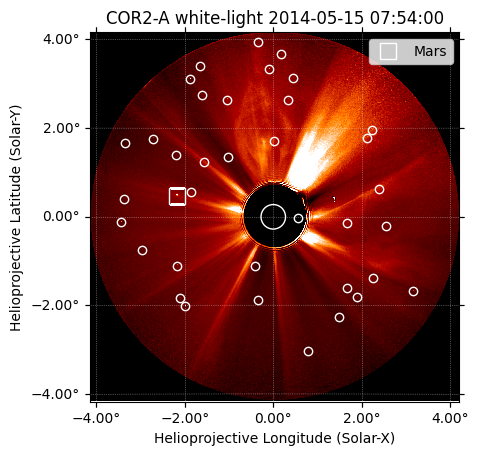

In [10]:
fig = plt.figure()
ax = fig.add_subplot(projection=cor2_map)

# Let's tweak the axis to show in degrees instead of arcsec
lon, lat = ax.coords
lon.set_major_formatter('d.dd')
lat.set_major_formatter('d.dd')

cor2_map.plot(axes=ax, vmin=0, vmax=600)
cor2_map.draw_limb(axes=ax)

# Plot the position of Mars
ax.plot_coord(mars, 's', color='white', fillstyle='none', markersize=12, label='Mars')
# Plot all of the stars
ax.plot_coord(tbl_crds, 'o', color='white', fillstyle='none')
ax.legend()

out = Path("STEREO_SECCHI_starfield_output.png")
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved {out.resolve()}")
plt.show()

